<a href="https://colab.research.google.com/github/mustafabayomi/-_-_-/blob/main/European_Soccer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import sqlite3
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

print("✔ # Imports completed successfully")

✔ # Imports completed successfully


In [ ]:
path = kagglehub.dataset_download("hugomathien/soccer")

print("✔ # Dataset Download completed")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'soccer' dataset.
✔ # Dataset Download completed
Dataset Path: /kaggle/input/soccer


In [ ]:
# Database Connection & Data Loading
database_path = os.path.join(path, 'database.sqlite')
conn = sqlite3.connect(database_path)

query = """
SELECT
    match_api_id,
    season,
    stage,
    home_team_api_id,
    away_team_api_id,
    home_team_goal,
    away_team_goal,
    date
FROM Match
"""

df = pd.read_sql_query(query, conn)

print("### Raw Dataset (Before Cleaning):")
print(df.head())
print("-" * 50)

### Raw Dataset (Before Cleaning):
   match_api_id     season  stage  home_team_api_id  away_team_api_id  \
0        492473  2008/2009      1              9987              9993   
1        492474  2008/2009      1             10000              9994   
2        492475  2008/2009      1              9984              8635   
3        492476  2008/2009      1              9991              9998   
4        492477  2008/2009      1              7947              9985   

   home_team_goal  away_team_goal                 date  
0               1               1  2008-08-17 00:00:00  
1               0               0  2008-08-16 00:00:00  
2               0               3  2008-08-16 00:00:00  
3               5               0  2008-08-17 00:00:00  
4               1               3  2008-08-16 00:00:00  
--------------------------------------------------


In [ ]:
# Missing Values Check

print("Missing Values Before Cleaning:")
print(df.isnull().sum())
print("-" * 50)

Missing Values Before Cleaning:
match_api_id        0
season              0
stage               0
home_team_api_id    0
away_team_api_id    0
home_team_goal      0
away_team_goal      0
date                0
dtype: int64
--------------------------------------------------


In [ ]:
# Missing Values Check
print("القيم المفقودة قبل التنظيف:")
print(df.isnull().sum())
print("-" * 30)

القيم المفقودة قبل التنظيف:
match_api_id        0
home_team_api_id    0
away_team_api_id    0
home_team_goal      0
away_team_goal      0
date                0
dtype: int64
------------------------------


In [ ]:
# Data Cleaning

df['date'] = pd.to_datetime(df['date'])

df.dropna(inplace=True)
df.drop_duplicates(subset=['match_api_id'], inplace=True)

df = df[(df['home_team_goal'] < 15) & (df['away_team_goal'] < 15)]

print("✔ Data Cleaning Completed Successfully")

✔ Data Cleaning Completed Successfully


In [ ]:
# Target Creation

def create_target(row):
    if row['home_team_goal'] > row['away_team_goal']:
        return 1
    elif row['home_team_goal'] < row['away_team_goal']:
        return -1
    else:
        return 0

df['target_result'] = df.apply(create_target, axis=1)

print("### Dataset After Cleaning & Target Creation:")
print(df[['season','stage','home_team_api_id','away_team_api_id','target_result']].head())

### Dataset After Cleaning & Target Creation:
      season  stage  home_team_api_id  away_team_api_id  target_result
0  2008/2009      1              9987              9993              0
1  2008/2009      1             10000              9994              0
2  2008/2009      1              9984              8635             -1
3  2008/2009      1              9991              9998              1
4  2008/2009      1              7947              9985             -1


In [ ]:
# Feature Selection

features = ['season', 'stage', 'home_team_api_id', 'away_team_api_id']

X = df[features]
y = df['target_result']

print("### Simplified Feature Set:")
print(X.head())

print("\nTarget Values:")
print(y.head())

### Simplified Feature Set:
      season  stage  home_team_api_id  away_team_api_id
0  2008/2009      1              9987              9993
1  2008/2009      1             10000              9994
2  2008/2009      1              9984              8635
3  2008/2009      1              9991              9998
4  2008/2009      1              7947              9985

Target Values:
0    0
1    0
2   -1
3    1
4   -1
Name: target_result, dtype: int64


In [ ]:
# Encoding

le = LabelEncoder()
X['season'] = le.fit_transform(X['season'])

print("✔ Categorical Encoding Completed")

✔ Categorical Encoding Completed


/tmp/ipykernel_10867/2332617996.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['season'] = le.fit_transform(X['season'])


In [ ]:
# Missing Values After Processing


print("Missing Values Before Dropping:")
print(df[features + ['target_result']].isnull().sum())

df.dropna(subset=features + ['target_result'], inplace=True)

print("-" * 50)
print("Missing Values After Cleaning:", df.isnull().sum().sum())
print("Final Dataset Shape:", df.shape)

Missing Values Before Dropping:
season              0
stage               0
home_team_api_id    0
away_team_api_id    0
target_result       0
dtype: int64
--------------------------------------------------
Missing Values After Cleaning: 0
Final Dataset Shape: (25979, 9)


In [ ]:
# Train-Test Split


X = df[features]
y = df['target_result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

print("\nTraining Distribution:")
print(y_train.value_counts(normalize=True))

Training Set Shape: (20783, 4)
Testing Set Shape: (5196, 4)

Training Distribution:
target_result
 1    0.458692
-1    0.287398
 0    0.253909
Name: proportion, dtype: float64


In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)


from sklearn.metrics import accuracy_score
log_acc = accuracy_score(y_test, log_model.predict(X_test))
print(f"The model's accuracy is: {log_acc:.2%}")

The model's accuracy is: 46.48%


In [ ]:
# Decision Tree

dt_model = DecisionTreeClassifier(max_depth=10)
dt_model.fit(X_train, y_train)

dt_acc = accuracy_score(y_test, dt_model.predict(X_test))

print(f"Decision Tree Accuracy: {dt_acc:.2%}")

Decision Tree Accuracy: 45.48%


In [ ]:
# KNN Model

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_acc = accuracy_score(y_test, knn_model.predict(X_test))

print(f"KNN Accuracy: {knn_acc:.2%}")

KNN Accuracy: 40.70%


In [ ]:
# SVM Model

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

svm_acc = accuracy_score(y_test, svm_model.predict(X_test))

print(f"SVM Accuracy: {svm_acc:.2%}")

SVM Accuracy: 46.52%


In [ ]:
# Naive Bayes Model

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_acc = accuracy_score(y_test, nb_model.predict(X_test))

print(f"Naive Bayes Accuracy: {nb_acc:.2%}")

Naive Bayes Accuracy: 46.52%


In [ ]:
# Model Comparison (

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        log_acc,
        dt_acc,
        knn_acc,
        svm_acc,
        nb_acc
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100
results = results.sort_values(by="Accuracy (%)", ascending=False)
print("### Model Comparison Results (%) ###")
print(results[["Model", "Accuracy (%)"]])

### Model Comparison Results (%) ###
                 Model  Accuracy (%)
4          Naive Bayes     46.516551
3                  SVM     46.516551
0  Logistic Regression     46.478060
1        Decision Tree     45.477290
2                  KNN     40.704388


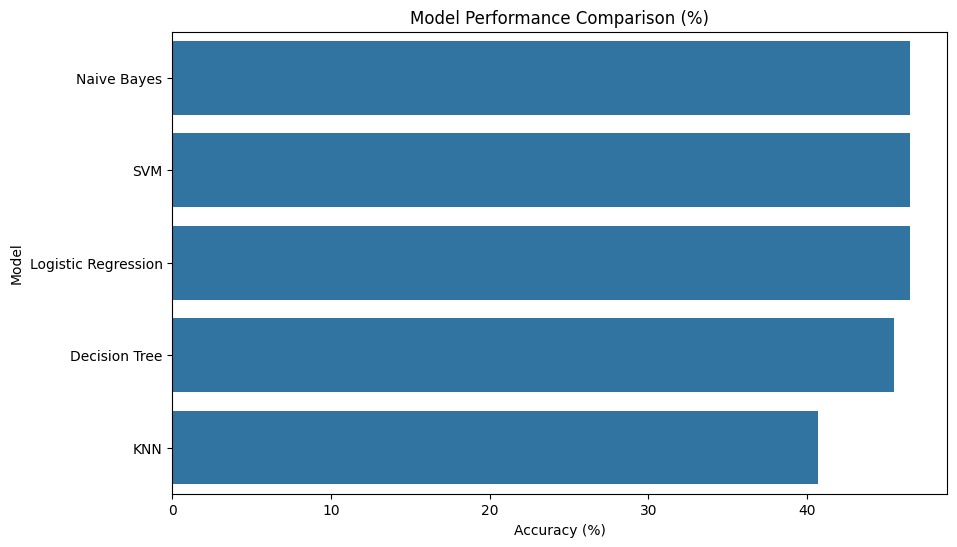

✔ Visualization completed successfully


In [ ]:
# Final Visualization

plt.figure(figsize=(10,6))
sns.barplot(x="Accuracy (%)", y="Model", data=results)

plt.title("Model Performance Comparison (%)")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")

plt.show()

print("✔ Visualization completed successfully")

In [ ]:
print("""
✔ Project Completed Successfully

- Data loaded from Kaggle dataset
- Data cleaning applied successfully
- Features selected and engineered
- Multiple ML models trained
- Best model identified using accuracy
- Results visualized successfully
""")


✔ Project Completed Successfully

- Data loaded from Kaggle dataset
- Data cleaning applied successfully
- Features selected and engineered
- Multiple ML models trained
- Best model identified using accuracy
- Results visualized successfully

